In [1]:
import matplotlib.pyplot as plt
import torch

from score.score import Score1d
from score.distributions import standard_gaussian_1d

In [2]:
model = torch.nn.Sequential(
    torch.nn.Linear(1, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 128),
    torch.nn.Softplus(),
    torch.nn.Linear(128, 1))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
score = Score1d(model, optimizer, standard_gaussian_1d())

In [3]:
loss, grad_norm = score.learn(
	n_samples_per_iter = 1000,
	n_iters = 500,
)

100%|██████████| 500/500 [00:02<00:00, 179.25it/s]


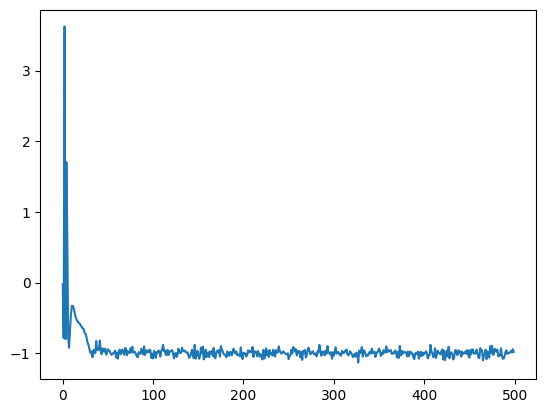

In [4]:
plt.plot(loss)

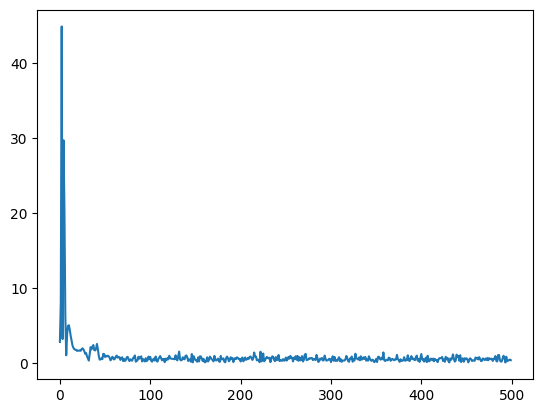

In [5]:
plt.plot(grad_norm)

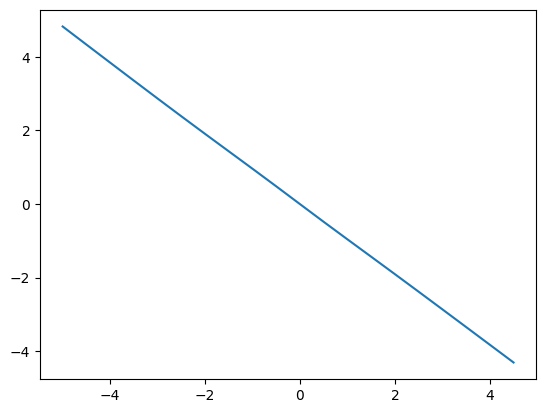

In [6]:
g, s = score.score_approx(-5, 5, 0.5)
g, s = g.numpy().T, s.numpy().T
plt.plot(g[0], s[0])

In [7]:
init_samples = 0.01 * standard_gaussian_1d().sample((1000, )) + 100
samples = score.sample_langevin(
	init_samples = init_samples,
	n_steps = 1000,
	epsilon = 0.1
)

100%|██████████| 1000/1000 [00:00<00:00, 1774.01it/s]


(array([  3.,  27.,  81., 167., 247., 242., 147.,  61.,  20.,   5.]),
 array([-3.38013887, -2.68812013, -1.99610126, -1.30408239, -0.61206359,
         0.07995522,  0.77197403,  1.46399283,  2.15601158,  2.84803057,
         3.54004931]),
 <BarContainer object of 10 artists>)

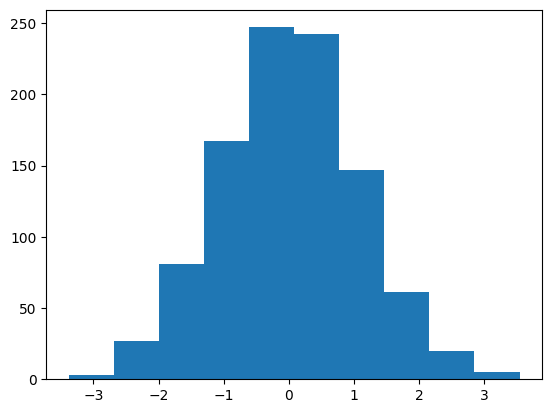

In [8]:
init_samples = init_samples.numpy().T
samples = samples.numpy().T
plt.hist(samples[0])